# Anàlisi de l'entrenament

Comparem els resultats del DQN i el NFSP entrenats amb 200.000 episodis.
Volem veure:
1. Si els models aprenen
2. Quin aprèn més ràpid
3. El resultat d'un enfrontament directe

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(r'c:\Users\ferri\Documents\ProjectesCodi\TFG-truc'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import logging

logging.basicConfig(level=logging.ERROR, force=True)

BASE = r'C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentRLCard\registres\03_3_26_a_les_2315'
LOG_DIR = os.path.join(BASE, 'logs')
MODEL_DIR = os.path.join(BASE, 'models')

dqn_df = pd.read_csv(os.path.join(LOG_DIR, 'dqn_log.csv'))
nfsp_df = pd.read_csv(os.path.join(LOG_DIR, 'nfsp_log.csv'))

print(f"DQN: {len(dqn_df)} registres, NFSP: {len(nfsp_df)} registres")

DQN: 100 registres, NFSP: 100 registres


## Aprenentatge

Avaluem si els models milloren. El reward va de -1 a +1. Contra un jugador aleatori, haurien d'arribar a ~0.9.

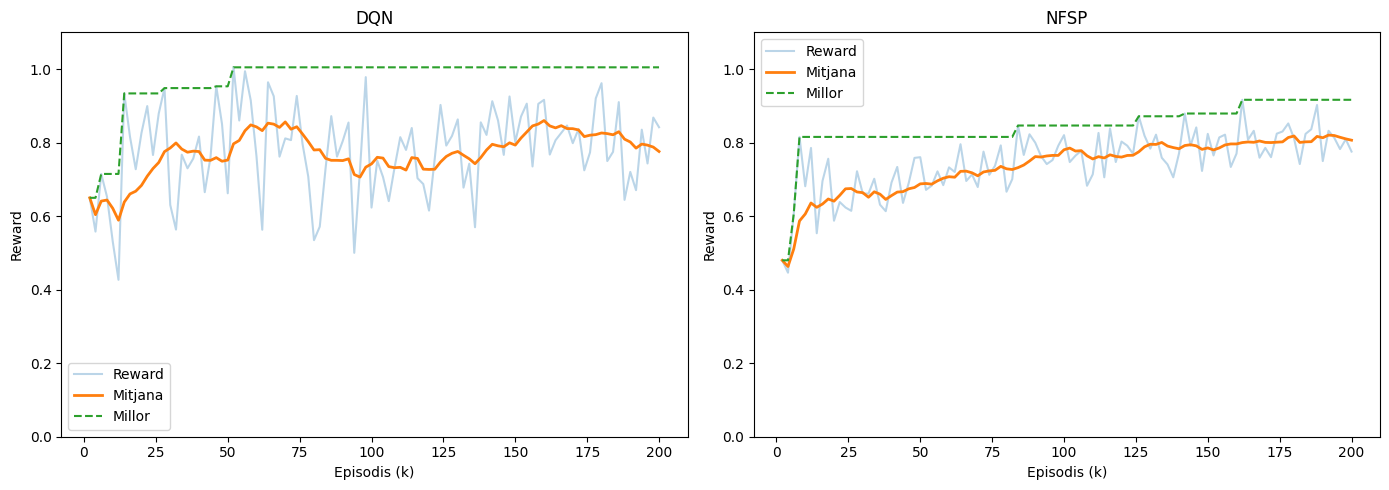

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DQN
ax = axes[0]
episodes = dqn_df['episodi'] / 1000
reward = dqn_df['reward_mig']
best = dqn_df['millor_historica']

rolling = reward.rolling(window=10, min_periods=1).mean()

ax.plot(episodes, reward, alpha=0.3, label='Reward')
ax.plot(episodes, rolling, linewidth=2, label='Mitjana')
ax.plot(episodes, best, linestyle='--', label='Millor')

ax.set_xlabel('Episodis (k)')
ax.set_ylabel('Reward')
ax.set_title('DQN')
ax.legend()
ax.set_ylim(0, 1.1)

# NFSP
ax = axes[1]
episodes_n = nfsp_df['episodi'] / 1000
reward_n = nfsp_df['reward_mig_p0']
best_n = nfsp_df['millor_historica']

rolling_n = reward_n.rolling(window=10, min_periods=1).mean()

ax.plot(episodes_n, reward_n, alpha=0.3, label='Reward')
ax.plot(episodes_n, rolling_n, linewidth=2, label='Mitjana')
ax.plot(episodes_n, best_n, linestyle='--', label='Millor')

ax.set_xlabel('Episodis (k)')
ax.set_ylabel('Reward')
ax.set_title('NFSP')
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Comparació DQN vs NFSP

Sobreposem les corbes per comparar.

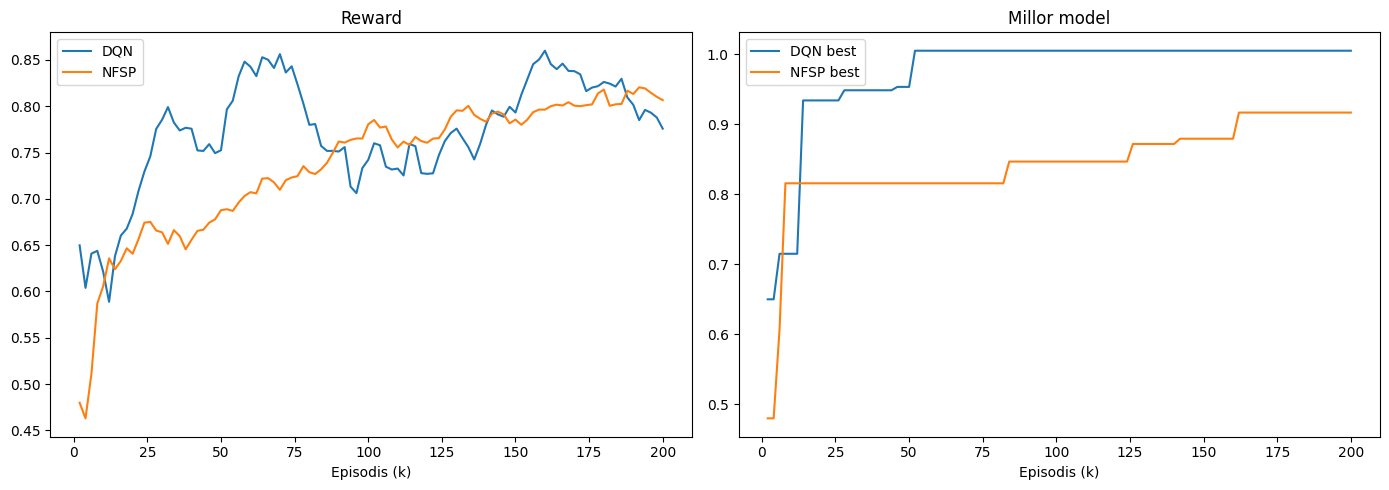

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

episodes_k = dqn_df['episodi'] / 1000

dqn_roll = dqn_df['reward_mig'].rolling(window=10, min_periods=1).mean()
nfsp_roll = nfsp_df['reward_mig_p0'].rolling(window=10, min_periods=1).mean()

ax1.plot(episodes_k, dqn_roll, label='DQN')
ax1.plot(episodes_k, nfsp_roll, label='NFSP')
ax1.set_xlabel('Episodis (k)')
ax1.set_title('Reward')
ax1.legend()

ax2.plot(episodes_k, dqn_df['millor_historica'], label='DQN best')
ax2.plot(episodes_k, nfsp_df['millor_historica'], label='NFSP best')
ax2.set_xlabel('Episodis (k)')
ax2.set_title('Millor model')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
dqn_rewards = dqn_df['reward_mig']
nfsp_rewards = nfsp_df['reward_mig_p0']

def stats_per_fase(rewards, episodis):
    fases = {
        '0-50k': episodis <= 50000,
        '50k-100k': (episodis > 50000) & (episodis <= 100000),
        '100k-150k': (episodis > 100000) & (episodis <= 150000),
        '150k-200k': (episodis > 150000),
    }
    rows = []
    for nom, mask in fases.items():
        r = rewards[mask]
        rows.append({
            'Fase': nom,
            'Reward': f"{r.mean():.4f}",
            'Std': f"{r.std():.4f}",
            'Max': f"{r.max():.4f}",
        })
    return pd.DataFrame(rows)

print("Estadístiques DQN")
display(stats_per_fase(dqn_rewards, dqn_df['episodi']))

print("\nEstadístiques NFSP")
display(stats_per_fase(nfsp_rewards, nfsp_df['episodi']))

Estadístiques DQN

,Fase,Reward,Std,Max
0,0-50k,0.7395,0.1371,0.9532
1,50k-100k,0.7903,0.1467,1.0048
2,100k-150k,0.7734,0.0928,0.9255
3,150k-200k,0.8142,0.0831,0.9617



Estadístiques NFSP

,Fase,Reward,Std,Max
0,0-50k,0.6618,0.0887,0.8155
1,50k-100k,0.7435,0.0520,0.8465
2,100k-150k,0.7799,0.0525,0.8792
3,150k-200k,0.8061,0.0453,0.9165


## Enfrontament final

Enfrontament definitiu entre els millors models de cada algorisme.
Utilitzem 500 partides alternant posicions.

In [5]:
NUM_FINAL = 500

print(f"Enfrontament final: DQN vs NFSP ({NUM_FINAL} partides)\n")

meitat = NUM_FINAL // 2
wins_dqn = 0
wins_nfsp = 0
total_reward_dqn = 0

env_final = crear_eval_env()
env_final.set_agents([dqn_best, nfsp_best])
for _ in range(meitat):
    _, payoffs = env_final.run(is_training=False)
    total_reward_dqn += payoffs[0]
    if payoffs[0] > payoffs[1]:
        wins_dqn += 1
    elif payoffs[1] > payoffs[0]:
        wins_nfsp += 1

env_final.set_agents([nfsp_best, dqn_best])
for _ in range(meitat):
    _, payoffs = env_final.run(is_training=False)
    total_reward_dqn += payoffs[1]
    if payoffs[1] > payoffs[0]:
        wins_dqn += 1
    elif payoffs[0] > payoffs[1]:
        wins_nfsp += 1

empats = NUM_FINAL - wins_dqn - wins_nfsp
wr_dqn = wins_dqn / NUM_FINAL
wr_nfsp = wins_nfsp / NUM_FINAL
reward_mig_dqn = total_reward_dqn / NUM_FINAL

print(f"  DQN:  {wins_dqn} victòries ({wr_dqn:.1%})")
print(f"  NFSP: {wins_nfsp} victòries ({wr_nfsp:.1%})")
print(f"  Empats: {empats}")
print(f"\n  Reward mig DQN: {reward_mig_dqn:.4f}")

guanyador = "DQN" if wins_dqn > wins_nfsp else ("NFSP" if wins_nfsp > wins_dqn else "Empat")
print(f"\n  Guanya: {guanyador}")

Enfrontament final: DQN vs NFSP (500 partides)


NameError: name 'crear_eval_env' is not defined

NameError: name 'wr_dqn' is not defined

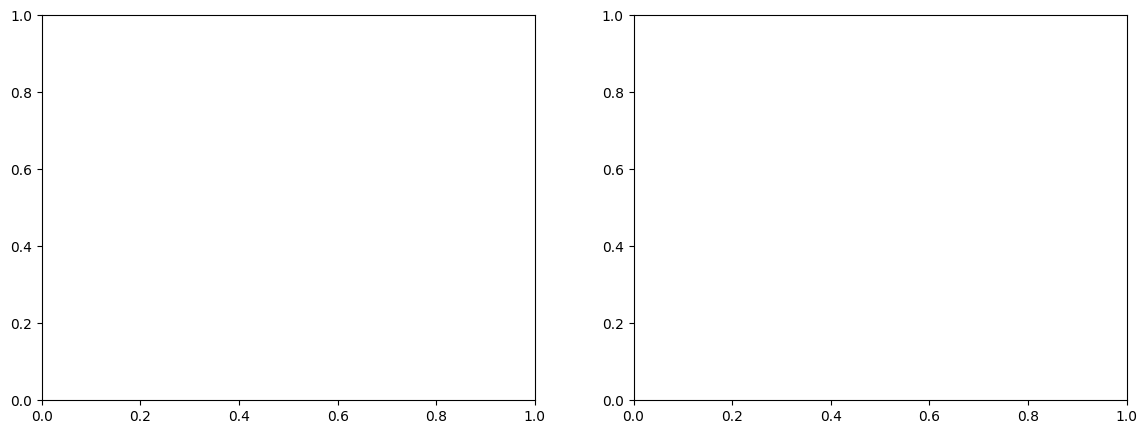

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = [f'DQN\n{wins_dqn} ({wr_dqn:.1%})', f'NFSP\n{wins_nfsp} ({wr_nfsp:.1%})']
sizes = [wins_dqn, wins_nfsp]

ax1.pie(sizes, labels=labels, autopct='', startangle=90)
ax1.set_title('Resultat Final: DQN vs NFSP')

categories = ['vs Random', 'Millor històric', 'vs Rival\n(winrate final)']
dqn_vals = [dqn_df[dqn_df['episodi']>150000]['reward_mig'].mean(),
            dqn_df['millor_historica'].iloc[-1],
            wr_dqn]
nfsp_vals = [nfsp_df[nfsp_df['episodi']>150000]['reward_mig_p0'].mean(),
             nfsp_df['millor_historica'].iloc[-1],
             wr_nfsp]

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, dqn_vals, width, label='DQN')
ax2.bar(x + width/2, nfsp_vals, width, label='NFSP')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()